<a href="https://colab.research.google.com/github/MohamedElashry18/Hand_sign_detection/blob/main/hand_sign_detection_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

train=pd.read_csv("/content/sign_mnist_train.csv")
test=pd.read_csv("/content/sign_mnist_test.csv")

In [ ]:
train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [ ]:
train['label'].unique()

array([ 3,  6,  2, 13, 16,  8, 22, 18, 10, 20, 17, 19, 21, 23, 24,  1, 12,
       11, 15,  4,  0,  5,  7, 14])

In [ ]:
print('train shape',str(train.shape),"\n test shape",test.shape)

train shape (27455, 785) 
 test shape (7172, 785)


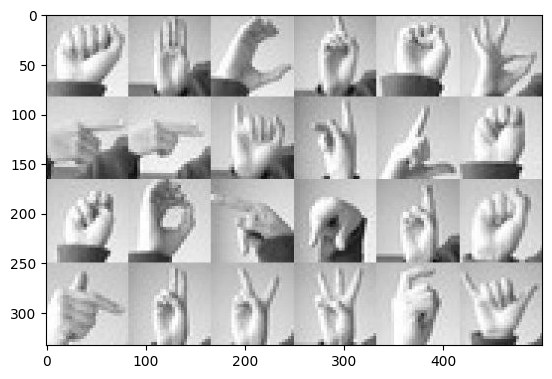

In [ ]:
import matplotlib.pyplot as plt
img=plt.imread("/content/IMG_20260718_175313_149.jpg")
plt.imshow(img)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.4039 - loss: 1.9612 - val_accuracy: 0.8554 - val_loss: 0.5747
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7708 - loss: 0.6992 - val_accuracy: 0.9568 - val_loss: 0.2066
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8688 - loss: 0.3867 - val_accuracy: 0.9887 - val_loss: 0.0799
Epoch 4/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9189 - loss: 0.2507 - val_accuracy: 0.9891 - val_loss: 0.0606
Epoch 5/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9393 - loss: 0.1809 - val_accuracy: 0.9982 - val_loss: 0.0186
Epoch 6/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9490 - loss: 0.1500 - val_accuracy: 0.9991 - val_loss: 0.0121
Epoch 7/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9611 - loss: 0.1146 - val_accuracy: 0.9996 - val_loss: 0.0057
Epoch 8/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9644 - loss: 0.1052 - val_accuracy: 0

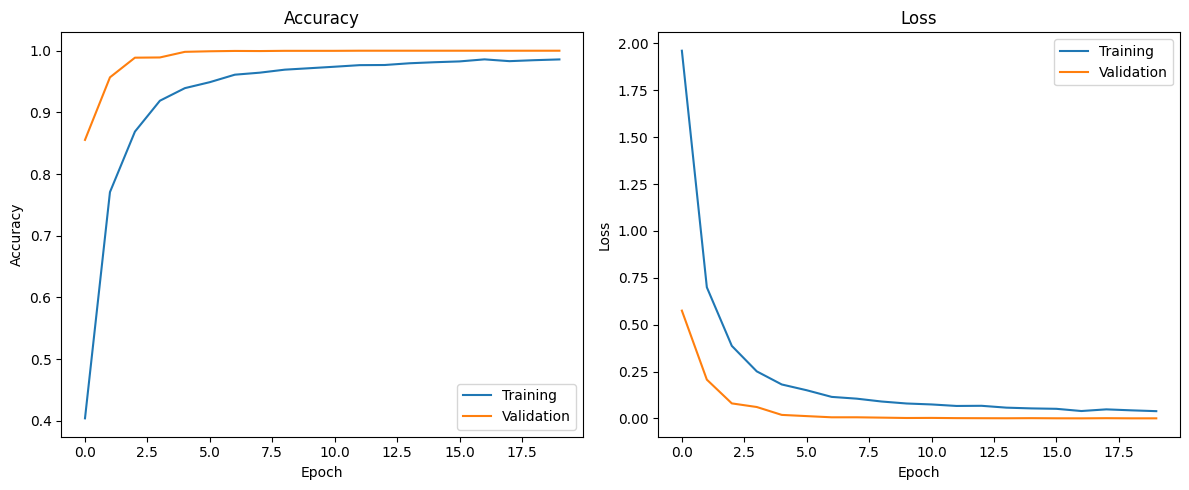


Model saved successfully!


In [ ]:
# ==========================
# Import Libraries
# ==========================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================
# Prepare Training Data
# ==========================

# Features
X_train = train.iloc[:, 1:].values

# Labels
y_train = train.iloc[:, 0].values

# Normalize
X_train = X_train.astype("float32") / 255.0

# Reshape to (28,28,1)
X_train = X_train.reshape(-1, 28, 28, 1)

# One-Hot Encoding
num_classes = 26
y_train = tf.keras.utils.to_categorical(y_train, num_classes)

# ==========================
# Prepare Test Data
# ==========================

X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

X_test = X_test.astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)

y_test = tf.keras.utils.to_categorical(y_test, num_classes)

# ==========================
# Build CNN Model
# ==========================

model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

# ==========================
# Compile Model
# ==========================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================
# Early Stopping
# ==========================

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# ==========================
# Train Model
# ==========================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# ==========================
# Evaluate Model
# ==========================

loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# ==========================
# Plot Accuracy
# ==========================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ==========================
# Plot Loss
# ==========================

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# ==========================
# Save Model
# ==========================

model.save("model_hand_sign.keras")

print("\nModel saved successfully!")

In [ ]:
!pip install cvzone
!pip install mediapipe

In [ ]:
import math

import cv2
import numpy as np
from cvzone.HandTrackingModule import HandDetector
from tensorflow.keras.models import load_model
from keras.src.layers.core.dense import Dense


orig_init = Dense.__init__


def patched_init(self, *args, **kwargs):
    kwargs.pop("quantization_config", None)
    return orig_init(self, *args, **kwargs)


Dense.__init__ = patched_init


class FallbackHandDetector:
    def findHands(self, img):
        img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        lower_skin = np.array([0, 40, 80], dtype=np.uint8)
        upper_skin = np.array([30, 255, 255], dtype=np.uint8)
        lower_skin2 = np.array([170, 40, 80], dtype=np.uint8)
        upper_skin2 = np.array([180, 255, 255], dtype=np.uint8)

        mask1 = cv2.inRange(img_hsv, lower_skin, upper_skin)
        mask2 = cv2.inRange(img_hsv, lower_skin2, upper_skin2)
        mask = cv2.bitwise_or(mask1, mask2)
        mask = cv2.GaussianBlur(mask, (9, 9), 0)

        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return [], img

        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        if area < 1000:
            return [], img

        x, y, w, h = cv2.boundingRect(largest)
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        return [{"bbox": (x, y, w, h)}], img


def load_hand_sign_model(model_path="model_hand_sign.keras"):
    return load_model(model_path, compile=False)


def main():
    labels = [
        'A','B','C','D','E','F','G','H','I','J',
        'K','L','M','N','O','P','Q','R','S','T',
        'U','V','W','X','Y','Z'
    ]

    model = load_hand_sign_model("model_hand_sign.keras")

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Unable to access the camera.")
        return

    try:
        detector = HandDetector(maxHands=1)
    except Exception as exc:
        print(f"HandDetector initialization failed: {exc}")
        print("Using fallback hand detection.")
        detector = FallbackHandDetector()

    offset = 20
    imgSize = 400

    try:
        while True:
            success, img = cap.read()

            if not success:
                print("Failed to capture image from camera, exiting.")
                break

            hands, img = detector.findHands(img)

            if hands:
                hand = hands[0]
                x, y, w, h = hand['bbox']

                imgWhite = np.ones((imgSize, imgSize, 3), np.uint8) * 255

                imgCrop = img[
                    max(0, y-offset):y+h+offset,
                    max(0, x-offset):x+w+offset
                ]

                aspectRatio = h / w

                if aspectRatio > 1:
                    k = imgSize / h
                    wCal = math.ceil(k * w)
                    imgResize = cv2.resize(imgCrop, (wCal, imgSize))
                    wGap = math.ceil((imgSize - wCal) / 2)
                    imgWhite[:, wGap:wGap+wCal] = imgResize
                else:
                    k = imgSize / w
                    hCal = math.ceil(k * h)
                    imgResize = cv2.resize(imgCrop, (imgSize, hCal))
                    hGap = math.ceil((imgSize - hCal) / 2)
                    imgWhite[hGap:hGap+hCal, :] = imgResize

                imgGray = cv2.cvtColor(imgWhite, cv2.COLOR_BGR2GRAY)
                imgGray = cv2.resize(imgGray, (28, 28))
                imgGray = imgGray.astype("float32") / 255.0
                imgGray = imgGray.reshape(1, 28, 28, 1)

                prediction = model.predict(imgGray, verbose=0)
                index = np.argmax(prediction)
                confidence = np.max(prediction)

                cv2.putText(
                    img,
                    f"{labels[index]} ({confidence:.2f})",
                    (x, y-20),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,
                    (0,255,0),
                    2
                )

                cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 255), 2)

            cv2.imshow("Image", img)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    finally:
        cap.release()
        cv2.destroyAllWindows()


if __name__ == "__main__":
    main()

Unable to access the camera.
